In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon')
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon\raman_simulation')
import useful_funcs
import simulation as s
from scipy.optimize import curve_fit
from uncertainties import *

cb_d = (106/255, 139/255,239/255)
cb_l = (158/255, 190/255,255/255)
cr_d = (214/255, 82/255,68/255)
cr_l = (244/255, 152/255,122/255)

## simulate fit beam parameters

In [2]:
params = np.array([31.51722131006443*1e-6, 0.07554338311557529, 0.0015936239200809305, 30.00092487180367*1e-6, 6.282981751066775])

In [3]:
sim_two_photon = s.sim(ls_order = 2, ls_854 = 2*np.pi*0.5*1e6)
sim_two_photon.get_rabi_frequencies()
sim_two_photon.carrier = True
sim_two_photon.counter_rot = True
sim_two_photon.F_states = True
sim_two_photon.get_f()

sim_two_photon.w0r = params[0]
sim_two_photon.r_sp = params[1]
sim_two_photon.r_pi = params[2]
sim_two_photon.w0b = params[3]
sim_two_photon.b_sp = 0.3355
sim_two_photon.b_pi = 0.329
sim_two_photon.ϕ = params[4]

In [4]:
Pb = sim_two_photon.RID_rpi*1e-3
sim_two_photon.power_scaling(Pb)

power scan progress:   0%|          | 0/24 [00:00<?, ?it/s]

spectroscopy, Pb = 180.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 152.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 130.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 112.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

...

spectroscopy, Pb = 24.3 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 22.8 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 21.4 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 19.9 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 18.8 mW:   0%|          | 0/40 [00:00<?, ?it/s]

In [3]:
sim_four_photon = s.sim(ls_order = 2)
sim_four_photon.get_rabi_frequencies()
sim_four_photon.carrier = False
sim_four_photon.counter_rot = True
sim_four_photon.F_states = True
sim_four_photon.get_f()

sim_four_photon.w0r = params[0]
sim_four_photon.r_sp = params[1]
sim_four_photon.r_pi = params[2]
sim_four_photon.w0b = params[3]
sim_four_photon.b_sp = 0.3355
sim_four_photon.b_pi = 0.329
sim_four_photon.ϕ = params[4]

In [5]:
Pb = sim_four_photon.RID_rpi*1e-3
sim_four_photon.power_scaling(Pb)

power scan progress:   0%|          | 0/24 [00:00<?, ?it/s]

spectroscopy, Pb = 180.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 152.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 130.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 112.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

...

spectroscopy, Pb = 24.3 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 22.8 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 21.4 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 19.9 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 18.8 mW:   0%|          | 0/40 [00:00<?, ?it/s]

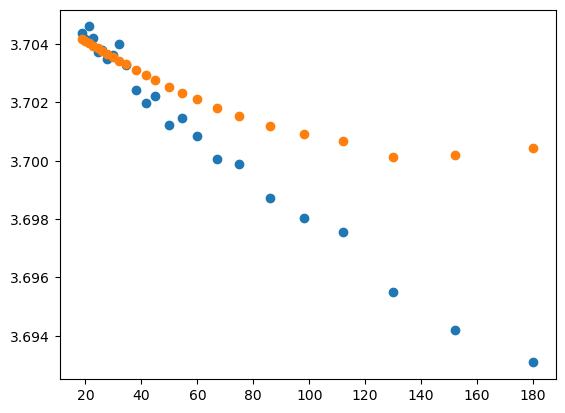

In [12]:
res_exp = sim_four_photon.res_4
res2 = sim_four_photon.ω0 + sim_four_photon.δ02_bank/2 - sim_four_photon.δ32_bank/2

res_num = sim_four_photon.w_num_bank

plt.figure()
plt.scatter(Pb*1e3, res_exp/1e6)
plt.scatter(Pb*1e3, res_num/(2*np.pi*1e6))

plt.show()

In [7]:
sim_six_photon = s.sim(ls_order = 8, transition = '+5/2<->-3/2')
sim_six_photon.get_rabi_frequencies()
sim_six_photon.carrier = False
sim_six_photon.counter_rot = True
sim_six_photon.F_states = True
sim_six_photon.get_f()

sim_six_photon.w0r = params[0]
sim_six_photon.r_sp = params[1]
sim_six_photon.r_pi = params[2]
sim_six_photon.w0b = params[3]
sim_six_photon.b_sp = 0.3355
sim_six_photon.b_pi = 0.329
sim_six_photon.ϕ = params[4]

In [ ]:
Pb6 = sim_six_photon.RID_rpi[0:5]*1e-3
sim_six_photon.power_scaling(Pb6)

power scan progress:   0%|          | 0/5 [00:00<?, ?it/s]

spectroscopy, Pb = 180.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

In [ ]:
pcov = np.array([
    [ 8.59e-16, -1.77e-12, -1.94e-11,  3.77e-15,  2.73e-11],
    [-1.77e-12,  2.39e-08,  3.70e-08, -9.96e-12, -5.88e-07],
    [-1.94e-11,  3.70e-08,  5.28e-07, -1.02e-10, -4.50e-07],
    [ 3.77e-15, -9.96e-12, -1.02e-10,  4.36e-14,  1.60e-10],
    [ 2.73e-11, -5.88e-07, -4.50e-07,  1.60e-10,  1.49e-05]
])

In [ ]:
(w0r, r_sp, r_pi, w0b, ϕ) = correlated_values(params, pcov)
b_sp = 0.3355
b_pi = 0.329
δb_sp = 0.0005
δb_pi = 0.001
b_sp = ufloat(b_sp, δb_sp)
b_pi = ufloat(b_pi, δb_pi)

In [ ]:
sim_four_photon.w0r = w0r
sim_four_photon.r_sp = r_sp
sim_four_photon.r_pi = r_pi
sim_four_photon.w0b = w0b
sim_four_photon.b_sp = b_sp
sim_four_photon.b_pi = b_pi
sim_four_photon.ϕ = ϕ

sim_six_photon.w0r = w0r
sim_six_photon.r_sp = r_sp
sim_six_photon.r_pi = r_pi
sim_six_photon.w0b = w0b
sim_six_photon.b_sp = b_sp
sim_six_photon.b_pi = b_pi
sim_six_photon.ϕ = ϕ

In [ ]:
sim_four_photon.analytics(Pb, sim_resonance = sim_four_photon.w_num_bank)
sim_six_photon.ls_order = 2
sim_six_photon.analytics(Pb6, sim_resonance = sim_six_photon.w_num_bank)

In [ ]:
Ω4 = abs((-sim_four_photon.Ω03_4 - sim_four_photon.Ω03_6)/(2*np.pi*1e3))
Ω6 = abs((sim_six_photon.Ω04_6)/(2*np.pi*1e3))

In [ ]:
Ω4_an = np.array(())
Ω4_er = np.array(())

for i in range(len(Ω4)):
    Ω4_an = np.append(Ω4_an, Ω4[i].nominal_value)
    Ω4_er = np.append(Ω4_er, Ω4[i].std_dev)

In [ ]:
Ω6_an = np.array(())
Ω6_er = np.array(())

for i in range(len(Ω6)):
    Ω6_an = np.append(Ω6_an, Ω6[i].nominal_value)
    Ω6_er = np.append(Ω6_er, Ω6[i].std_dev)

In [ ]:
Ω2_num = abs(sim_two_photon.Ω_num_bank/(2*np.pi*1e3))
Ω4_num = abs(sim_four_photon.Ω_num_bank/(2*np.pi*1e3))
Ω6_num = abs(sim_six_photon.Ω_num_bank/(2*np.pi*1e3))

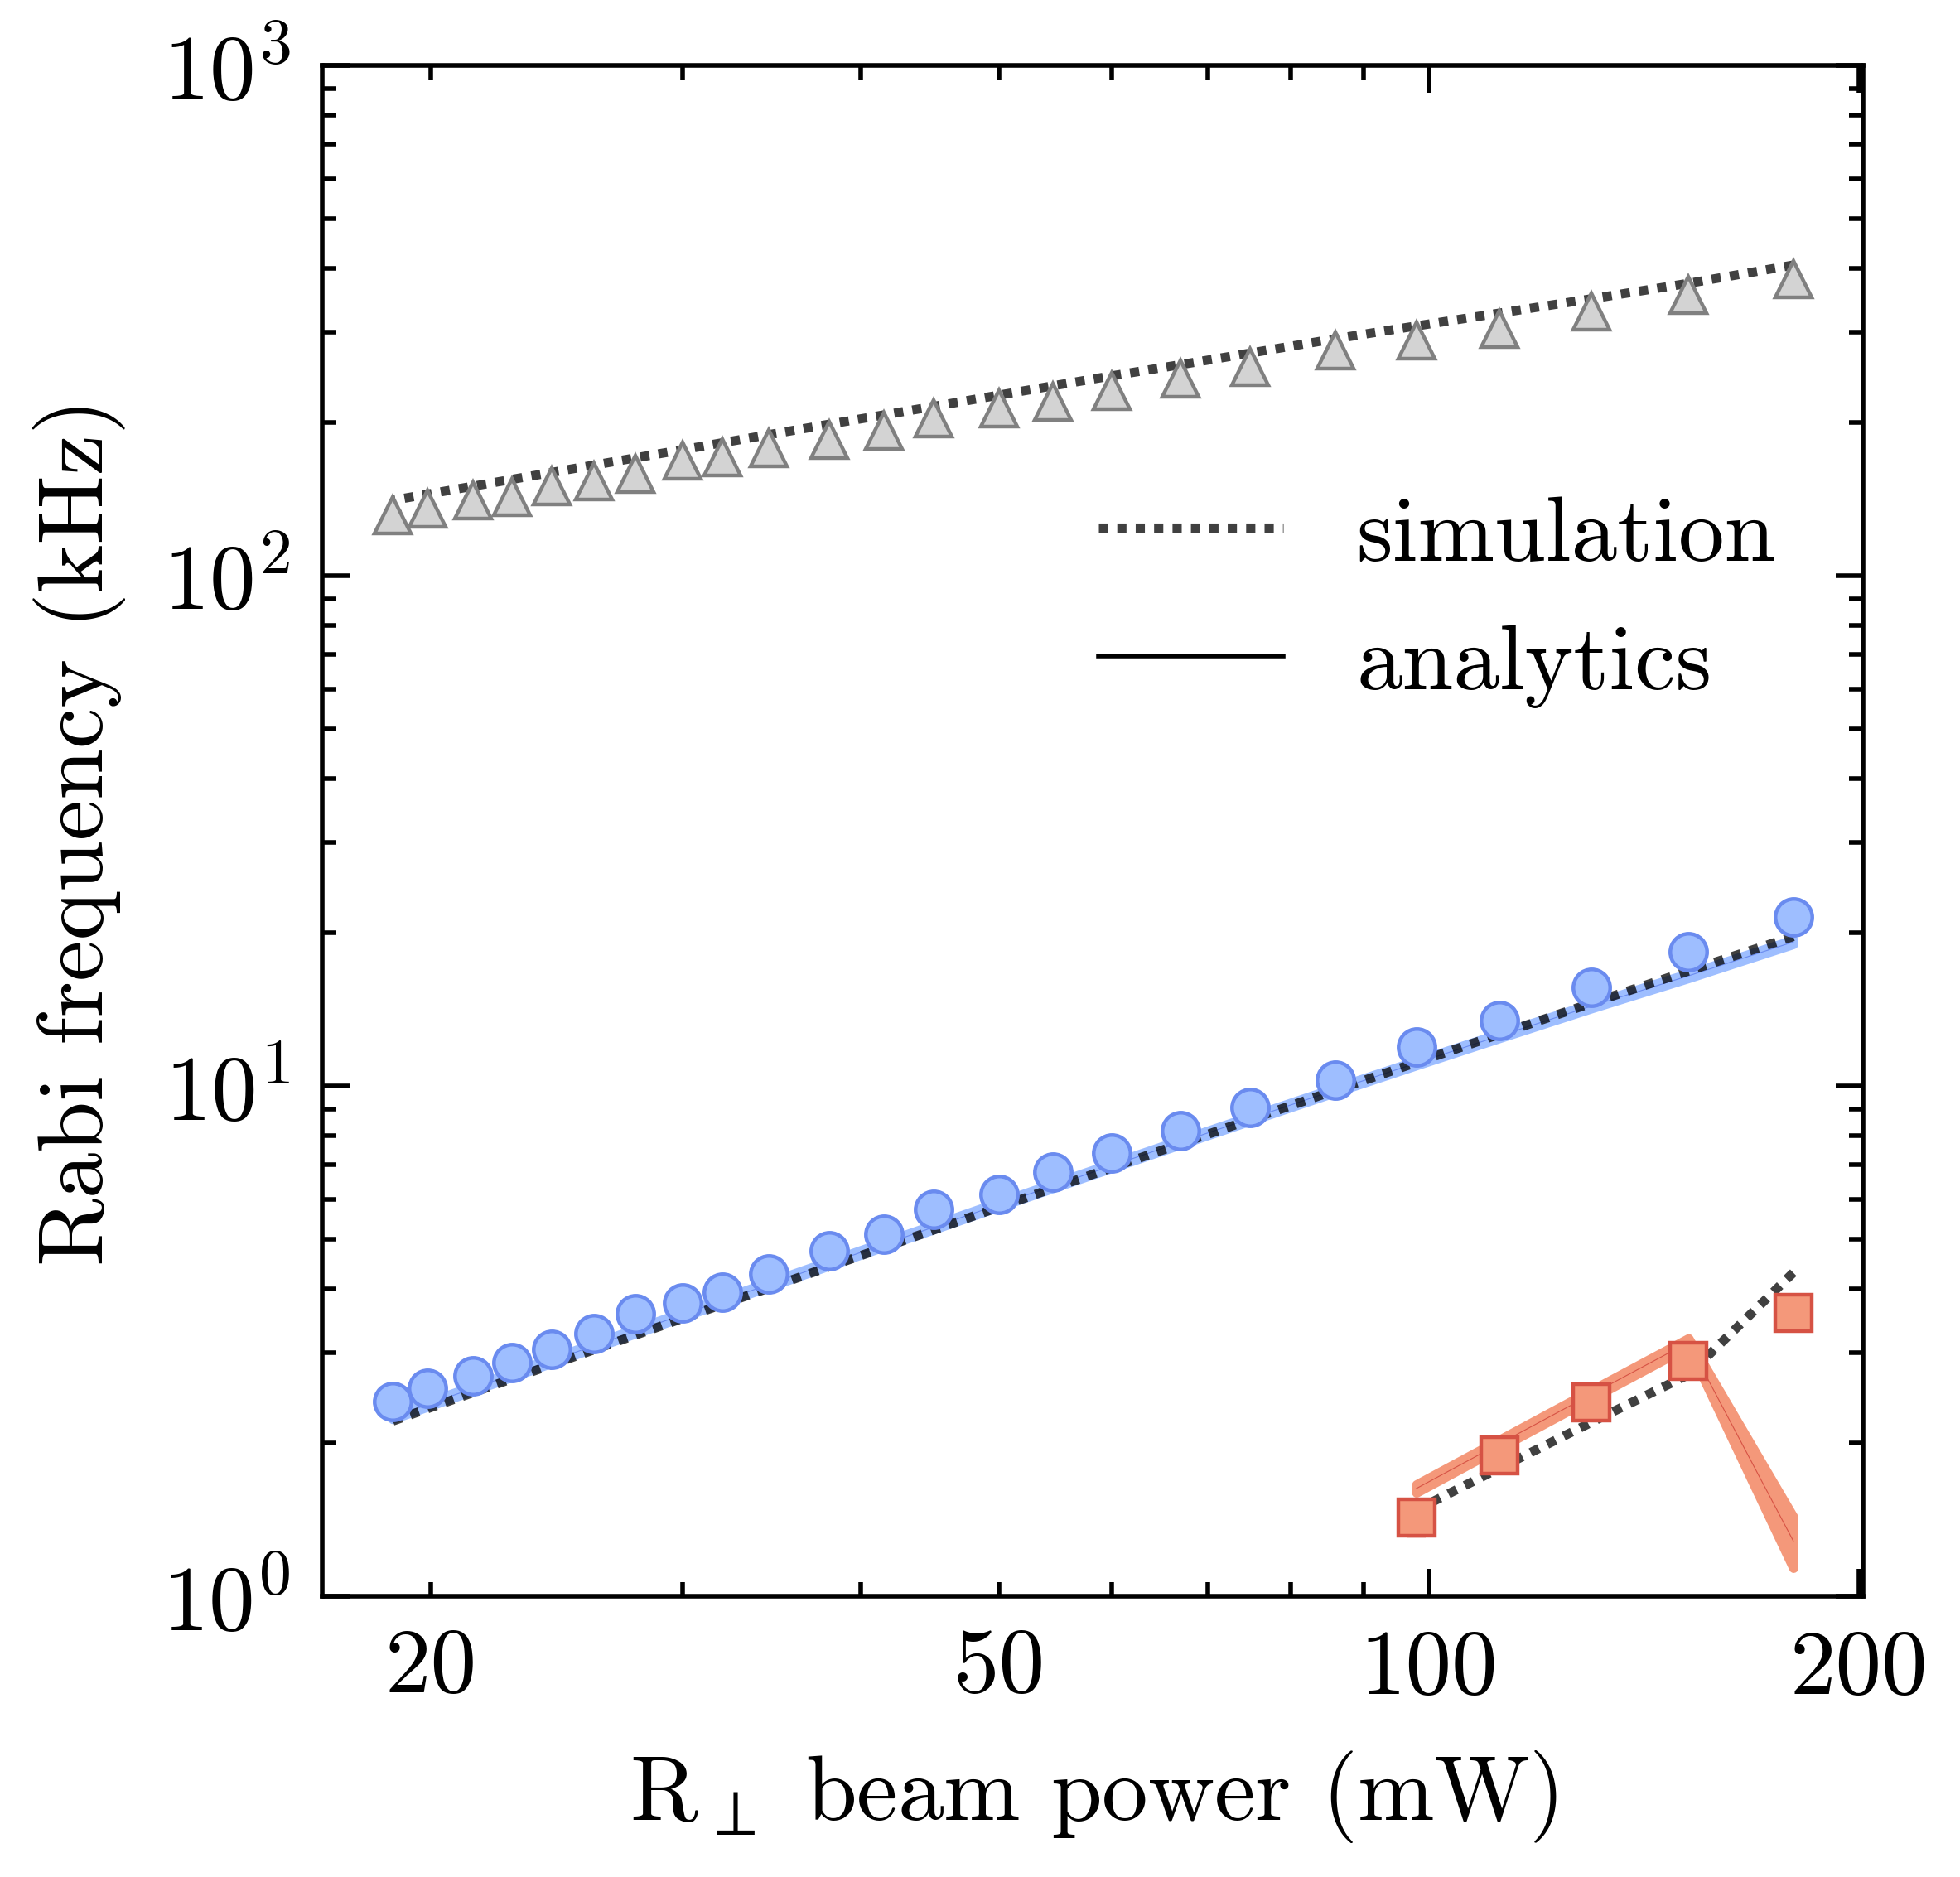

In [21]:
with plt.style.context(['science','no-latex']):
    plt.figure(dpi = 800, figsize = (3,3))

    
    plt.errorbar(Pb*1e3,(np.pi/sim_four_photon.tpi_2)/(2*np.pi*1e3), 
                 (np.pi*sim_four_photon.δtpi_2/sim_four_photon.tpi_2**2)/(2*np.pi*1e3), marker = '^' , ls = 'none', ecolor = 'grey', markeredgecolor = 'grey', markeredgewidth = .4, 
                 markersize=4, capsize=1, elinewidth = .5,markerfacecolor='lightgray', alpha = 1)
    
    plt.errorbar(Pb*1e3,(np.pi/sim_four_photon.tpi_4)/(2*np.pi*1e3), 
                 (np.pi*sim_four_photon.δtpi_4/sim_four_photon.tpi_4**2)/(2*np.pi*1e3), marker = '.' , ls = 'none', ecolor = cb_d, markeredgecolor = cb_d, markeredgewidth = .4, 
                 markersize=8, capsize=1, elinewidth = .5,markerfacecolor=cb_l, alpha = 1)
    
      
    plt.errorbar(Pb6*1e3,(np.pi/sim_six_photon.tpi_6)/(2*np.pi*1e3), 
                 (np.pi*sim_six_photon.δtpi_6/sim_six_photon.tpi_6**2)/(2*np.pi*1e3), marker = 's' , ls = 'none', ecolor = cr_d, markeredgecolor = cr_d, markeredgewidth = .4, 
                 markersize=4, capsize=1, elinewidth = .5,markerfacecolor=cr_l, alpha = 1)
    m = 1
    alpha = .75
    dashes=[m,m]
    plt.plot(Pb*1e3, Ω2_num, color = 'black',dashes= dashes, linewidth = m, alpha = alpha)
    
    
    plt.plot(Pb*1e3, Ω4_an, color = cb_d, linewidth = 0.1)
    plt.fill_between(Pb*1e3, Ω4_an + Ω4_er, Ω4_an - Ω4_er, color = cb_l, alpha = 1)
    plt.plot(Pb*1e3, Ω4_num, color = 'black',dashes= dashes, linewidth = m, alpha = alpha)
    
    plt.plot(Pb6*1e3,Ω6_an, color = cr_d, linewidth = 0.1)
    plt.fill_between(Pb6*1e3, Ω6_an + Ω6_er, Ω6_an - Ω6_er, color = cr_l, alpha = 1)
    plt.plot(Pb6*1e3, Ω6_num, color = 'black',dashes= dashes, linewidth = m, alpha = alpha)
    
    
    
    plt.plot([-1], [-1], color = 'black',dashes= dashes, linewidth = m, alpha = alpha, label = 'simulation')
    plt.plot([-1], [-1], color = 'black', linewidth = .5, label = 'analytics')
    
    
    plt.axhline(0, color = 'black')
    # plt.xlim(0,200)
    plt.ylim(1, 1e3)
    # plt.grid(axis = 'y')
    plt.legend(loc='center left', bbox_to_anchor=(.45, .65))
    plt.ylabel('Rabi frequency (kHz)')
    plt.xlabel(r'R$_\perp$ beam power (mW)')
    plt.xscale('log')
    plt.yscale('log')
    
    from matplotlib.ticker import FuncFormatter

    plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:g}'))
    
    
    plt.xticks([100, 200])
    # plt.xticks([0, 5, 10])          # major ticks
    plt.gca().set_xticks([20, 30, 40, 50, 60, 70, 80, 90], minor=True) 
    plt.gca().set_xticklabels(['20','','','50','','','',''], minor=True)
    plt.tick_params(axis='x', which='minor', labelbottom=True)
    plt.show()

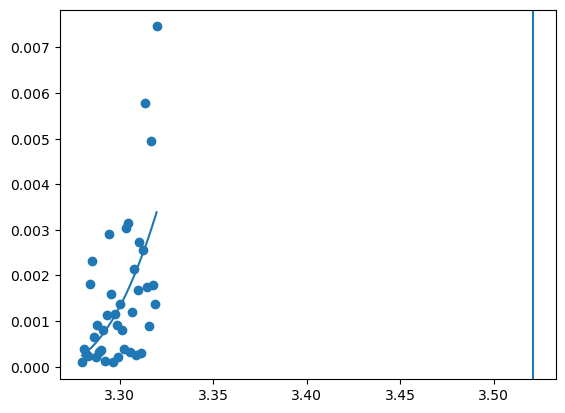

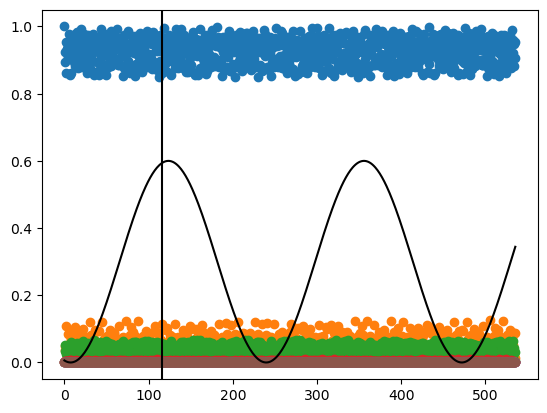

In [30]:
sim_six_photon.spot_check(0)